In [1]:
!pip install torchinfo

# Import Libraries

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import numpy as np
import cv2
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import platform
import psutil
import random
import glob
from tqdm import tqdm
from tqdm.notebook import tqdm
import PIL
from PIL import Image
from torchvision import transforms
from torchvision.transforms import RandAugment
from PIL import ImageOps
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import ImageEnhance, ImageOps, ImageFilter
import PIL, PIL.ImageOps, PIL.ImageEnhance, PIL.ImageDraw
from tabulate import tabulate

# Configuration

In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


# Varibales

In [4]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

data_dir = "/kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer/Brain Cancer"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mu = 4
lb_batch = 8
ulb_batch = mu*lb_batch
val_batch = 8
threshold_value = 0.80
total_class = 3
learning_rate = 0.0001
num_epochs = 10
patience = 10

checkpoints_path = "/kaggle/working/fixmatch_model.pt"

# Explore Dataset

In [5]:
file_paths = []
labels = []

for class_name in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, class_name)
    for image_name in os.listdir(class_dir):
        file_paths.append(os.path.join(class_dir, image_name))
        labels.append(class_name)

df = pd.DataFrame({"file_path": file_paths, "label": labels})
df = df.sample(frac=1).reset_index(drop=True)

Class: brain_glioma, Count: 5000
Class: brain_menin, Count: 5000
Class: brain_tumor, Count: 5000


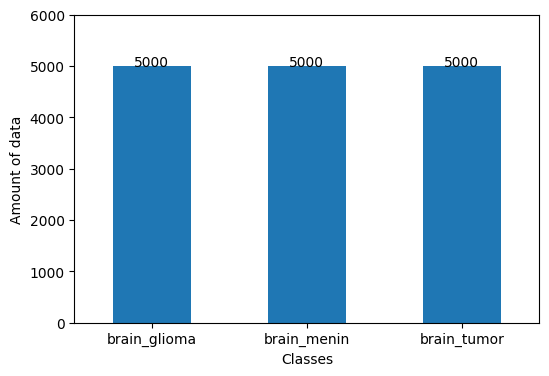

In [6]:
class_counts_train = df['label'].value_counts()

for class_name, count in class_counts_train.items():
    print(f"Class: {class_name}, Count: {count}")

plt.figure(figsize=(6, 4))
ax = class_counts_train.plot(kind='bar')
plt.xlabel('Classes')
plt.ylabel('Amount of data')
plt.xticks(rotation=360)
for i, count in enumerate(class_counts_train):
    ax.text(i, count + 5, str(count), ha='center')
plt.ylim(0, max(class_counts_train) * 1.2)
plt.show()

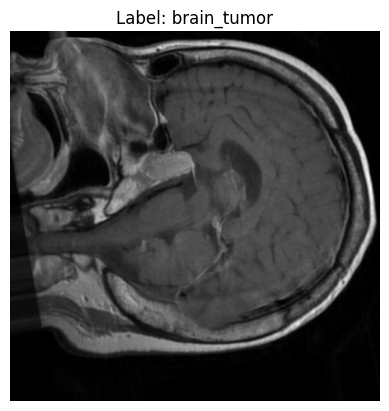

In [7]:
random_index = random.randint(1, len(df) - 1)
random_row = df.iloc[random_index]

file_path = random_row['file_path']
label = random_row['label']

image = Image.open(file_path)
plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# Data Splitting 

In [8]:
# Train, Test and Validation Set

train_dataframe, temp_dataframe = train_test_split(
    df, 
    test_size=0.3, 
    stratify=df['label'], 
    random_state=42
)

test_dataframe, valid_dataframe = train_test_split(
    temp_dataframe, 
    test_size=0.5, 
    stratify=temp_dataframe['label'], 
    random_state=42
)

In [9]:
# Labeled and Unlabeled Set

ulb_dataframe, lb_dataframe = train_test_split(
    train_dataframe, 
    test_size=0.2, 
    stratify=train_dataframe['label'], 
    random_state=42
)

# Data Distribution

In [10]:
print("Unlabeled Data: ", len(ulb_dataframe))
print("Labeled Data: ", len(lb_dataframe))
print("Validation Data: ", len(valid_dataframe))
print("Test Data: ", len(test_dataframe))
print("-------------------------------------------")
print("Total amounts of data in the dataset: ", len(data_dir))

Unlabeled Data:  8400
Labeled Data:  2100
Validation Data:  2250
Test Data:  2250
-------------------------------------------
Total amounts of data in the dataset:  88


In [11]:
class_counts_lb = lb_dataframe['label'].value_counts()
class_counts_ulb = ulb_dataframe['label'].value_counts()
class_counts_valid = valid_dataframe['label'].value_counts()
class_counts_test = test_dataframe['label'].value_counts()

lb_table_data = [[class_name, count] for class_name, count in class_counts_lb.items()]
ulb_table_data = [[class_name, count] for class_name, count in class_counts_ulb.items()]
valid_table_data = [[class_name, count] for class_name, count in class_counts_valid.items()]
test_table_data = [[class_name, count] for class_name, count in class_counts_test.items()]

print("Labeled Dataset")
print(tabulate(lb_table_data, headers=["Class", "Count"]))
print("\nUnlabeled Dataset")
print(tabulate(ulb_table_data, headers=["Class", "Count"]))
print("\nValidation Dataset")
print(tabulate(valid_table_data, headers=["Class", "Count"]))
print("\nTest Dataset")
print(tabulate(test_table_data, headers=["Class", "Count"]))

Labeled Dataset
Class           Count
------------  -------
brain_tumor       700
brain_glioma      700
brain_menin       700

Unlabeled Dataset
Class           Count
------------  -------
brain_tumor      2800
brain_menin      2800
brain_glioma     2800

Validation Dataset
Class           Count
------------  -------
brain_tumor       750
brain_menin       750
brain_glioma      750

Test Dataset
Class           Count
------------  -------
brain_glioma      750
brain_menin       750
brain_tumor       750


# Dataset Class, Dataloader and Transform

In [12]:
class ImageDatasetWithAugmentation(Dataset):
    def __init__(self, dataframe, weak_transform, strong_transform, normalize, is_lb=False):
        self.dataframe = dataframe
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform
        self.normalize = normalize
        self.is_lb = is_lb
        self.label_map = {'brain_glioma': 0, 'brain_menin': 1, 'brain_tumor': 2}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        image = PIL.Image.open(img_path)

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(self.weak_transform(image)), label
        else:
            weak_image = self.weak_transform(image)
            strong_image = self.strong_transform(image)
            return self.normalize(weak_image), self.normalize(strong_image)

In [13]:
class ImageDatasetNoAugmentation(Dataset):
    def __init__(self, dataframe, normalize, is_lb=False):
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        self.label_map = {'brain_glioma': 0, 'brain_menin': 1, 'brain_tumor': 2}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        image = PIL.Image.open(img_path)

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

In [14]:
def dynamic_magnitude_randaugment(image):
        magnitude = torch.randint(1, 31, (1,)).item()
        transform = transforms.Compose([
            RandAugment(num_ops=3, magnitude=magnitude)
        ])
        return transform(image)

def train_data_transform():
    weak_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=0, translate=(0.125, 0.125)),
    ])

    strong_transform = transforms.Lambda(dynamic_magnitude_randaugment)

    normalize = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()])

    ulb_dataset = ImageDatasetWithAugmentation (
        ulb_dataframe,
        weak_transform,
        strong_transform,
        normalize,
        is_lb=False
    )

    lb_dataset = ImageDatasetWithAugmentation(
        lb_dataframe,
        weak_transform,
        strong_transform,
        normalize,
        is_lb=True
    )

    dataloader_ulb_dataset = DataLoader(
        ulb_dataset, batch_size = 
        ulb_batch, 
        shuffle=True, 
        num_workers=2
    )
    
    dataloader_lb_dataset = DataLoader(
        lb_dataset, batch_size = 
        lb_batch, 
        shuffle=True, 
        num_workers=2
    )

    return dataloader_ulb_dataset, dataloader_lb_dataset

dataloader_ulb_dataset, dataloader_lb_dataset = train_data_transform()

In [15]:
def valid_data_transform():
    normalize = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()])

    valid_dataset = ImageDatasetNoAugmentation(
        valid_dataframe,
        normalize,
        is_lb=True
    )

    test_dataset = ImageDatasetNoAugmentation(
        test_dataframe,
        normalize,
        is_lb=True
    )

    dataloader_valid_dataset = DataLoader(
        valid_dataset, batch_size = 
        val_batch, 
        shuffle=False, 
        num_workers=2
    )
    
    dataloader_test_dataset = DataLoader(
        test_dataset, batch_size = 
        val_batch, 
        shuffle=False, 
        num_workers=2
    )

    return dataloader_valid_dataset, dataloader_test_dataset

dataloader_valid_dataset, dataloader_test_dataset = valid_data_transform()

# Neural Network (Teacher Model)

In [16]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'googlenet', pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, total_class)
)
model = model.to(device)
optimizer = optim.SGD(
    model.parameters(), 
    lr=learning_rate, 
    momentum=0.9
)
summary(model, input_size=(lb_batch, 3, 224, 224))

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 233MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [8, 3]                    --
├─BasicConv2d: 1-1                       [8, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [8, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [8, 64, 112, 112]         128
├─MaxPool2d: 1-2                         [8, 64, 56, 56]           --
├─BasicConv2d: 1-3                       [8, 64, 56, 56]           --
│    └─Conv2d: 2-3                       [8, 64, 56, 56]           4,096
│    └─BatchNorm2d: 2-4                  [8, 64, 56, 56]           128
├─BasicConv2d: 1-4                       [8, 192, 56, 56]          --
│    └─Conv2d: 2-5                       [8, 192, 56, 56]          110,592
│    └─BatchNorm2d: 2-6                  [8, 192, 56, 56]          384
├─MaxPool2d: 1-5                         [8, 192, 28, 28]          --
├─Inception: 1-6                         [8, 256, 28, 28]          --
│

# Semi Supervised Training

In [17]:
def train_fixMatch(model, optimizer, dataloader_lb_dataset, dataloader_ulb_dataset, device, threshold):
    model.train()
    losses = []
    correct_predictions = 0
    total_samples = 0
    total_unlabeled_samples = 0

    confidences = []
    num_confident_predictions = 0

    pbar = tqdm(dataloader_lb_dataset)
    ulb_iter = iter(dataloader_ulb_dataset)

    for batch_lb in pbar:
        model.zero_grad()

        # Labeled data
        x_lb, y = batch_lb
        x_lb, y = x_lb.to(device), y.to(device)

        # Unlabeled data
        try:
            x_weak, x_strong = next(ulb_iter)
        except StopIteration:
            ulb_iter = iter(dataloader_ulb_dataset)
            x_weak, x_strong = next(ulb_iter)

        x_weak, x_strong = x_weak.to(device), x_strong.to(device)
        total_unlabeled_samples += x_weak.size(0)

        # Concatenate all x
        all_x = torch.cat([x_lb, x_weak, x_strong], dim=0)

        # Compute logits
        all_logits = model(all_x)

        # Logits and loss for labeled data
        logits_lb = all_logits[:x_lb.size(0)]
        loss_lb = F.cross_entropy(logits_lb, y)

        # Logits for unlabeled data
        logits_ulb = all_logits[x_lb.size(0):]
        logits_weak, logits_strong = torch.chunk(logits_ulb, 2, dim=0)

        # Stop gradient for weak augmented
        logits_weak = logits_weak.detach()

        # Compute class probabilities
        probs_weak = F.softmax(logits_weak, dim=1)

        # Compute pseudo labels
        max_prob, pseudo_label = torch.max(probs_weak, dim=1)
        confidences.extend(max_prob.tolist())  # Track confidence

        # Mask for confident predictions
        mask = (max_prob > threshold).float()
        num_confident_predictions += mask.sum().item()  # Count confident predictions

        # Mask non-confident predictions
        pseudo_label = pseudo_label.masked_fill(mask == 0, 0)

        # Unsupervised loss by ignoring non-confident predictions
        loss_ulb = F.cross_entropy(logits_strong, pseudo_label, ignore_index=-1)

        # Total loss (consider weighting if needed)
        loss = loss_lb + loss_ulb

        # Compute accuracy for labeled data
        _, predicted = torch.max(logits_lb, 1)
        correct_predictions += (predicted == y).sum().item()
        total_samples += y.size(0)

        loss.backward()
        optimizer.step()

        loss_item = loss.item()
        losses.append(loss_item)

        pbar.set_description(f'train loss = {np.array(losses).mean():.3f}, accuracy = {correct_predictions / total_samples:.3f}')

    avg_confidence = sum(confidences) / len(confidences)
    confident_ratio = num_confident_predictions / total_unlabeled_samples

    return np.array(losses).mean(), correct_predictions / total_samples, avg_confidence, confident_ratio, num_confident_predictions, total_unlabeled_samples

In [18]:
def validate(model, dataloader, device):
    model.eval()
    correct_predictions = 0
    total_samples = 0
    val_losses = []

    with torch.no_grad():
        for batch in dataloader:
            x_val, y_val = batch
            x_val, y_val = x_val.to(device), y_val.to(device)

            logits_val = model(x_val)
            loss_val = F.cross_entropy(logits_val, y_val)

            _, predicted_val = torch.max(logits_val, 1)
            correct_predictions += (predicted_val == y_val).sum().item()
            total_samples += y_val.size(0)

            val_losses.append(loss_val.item())

    accuracy = correct_predictions / total_samples
    val_loss = np.array(val_losses).mean()

    return accuracy, val_loss

In [19]:
import time
start_time = time.time()

num_epochs_without_improvement = 0
num_epochs_loss_greater = 0

losses = []
accuracies = []
val_losses = []
val_accuracies = []
all_confident_predictions = []
all_confident_ratio = []
all_avg_confidence = []
best_val_accuracy = 0
prev_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss, train_accuracy, avg_confidence, confident_ratio, num_confident_predictions, total_unlabeled_samples = train_fixMatch(model, optimizer, dataloader_lb_dataset, dataloader_ulb_dataset, device, threshold=threshold_value)

    print(f"\nEpoch {epoch + 1}:")
    print(f"Average confidence: {avg_confidence:.3f}")
    print(f"Ratio of confident predictions: {num_confident_predictions:.1f}/{total_unlabeled_samples:.1f} = {confident_ratio:.3f}")

    val_accuracy, val_loss = validate(model, dataloader_valid_dataset, device)

    losses.append(train_loss)
    accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    all_confident_predictions.append(num_confident_predictions)
    all_confident_ratio.append(confident_ratio)
    all_avg_confidence.append(avg_confidence)

    print(f'Epoch {epoch + 1}/{num_epochs} - '
          f'Train Loss: {train_loss:.3f}, Train Accuracy: {train_accuracy:.3f} - '
          f'Validation Loss: {val_loss:.3f}, Validation Accuracy: {val_accuracy:.3f}')

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        filepath = checkpoints_path
        checkpoint = {
            "epoch": epoch + 1,
            "model_weight": model.state_dict(),
            "optimizer_state": optimizer.state_dict()
        }
        torch.save(checkpoint, filepath)
        print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_accuracy:.3f}")
        num_epochs_without_improvement = 0
    else:
        num_epochs_without_improvement += 1

    if val_loss > train_loss:
        num_epochs_loss_greater += 1
    else:
        num_epochs_loss_greater = 0

    if num_epochs_without_improvement >= patience or num_epochs_loss_greater >= patience:
        print(f"Early stopping criteria met. No improvement in validation accuracy or validation loss for {patience} consecutive epochs. Training stopped.")
        break

print("Training complete.........")

end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")

train_data = {
    'Epoch': range(1, len(losses) + 1),
    'Train_Loss': losses,
    'Train_Accuracy': accuracies,
    'Validation_Loss': val_losses,
    'Validation_Accuracy': val_accuracies,
    'Num_Confident_Predictions': all_confident_predictions,
    'Total_Unlabeled_Samples': total_unlabeled_samples,
    'Confident_Ratio': all_confident_ratio,
    'Avg_Confidence': all_avg_confidence
}

history = pd.DataFrame(train_data)
history.to_excel('/kaggle/working/training_logs.xlsx', index=False)

  0%|          | 0/263 [00:00<?, ?it/s]


Epoch 1:
Average confidence: 0.627
Ratio of confident predictions: 533.0/8400.0 = 0.063
Epoch 1/10 - Train Loss: 1.520, Train Accuracy: 0.356 - Validation Loss: 0.865, Validation Accuracy: 0.442
Best model saved at epoch 1 with validation accuracy: 0.442


  0%|          | 0/263 [00:00<?, ?it/s]


Epoch 2:
Average confidence: 0.634
Ratio of confident predictions: 2011.0/8400.0 = 0.239
Epoch 2/10 - Train Loss: 1.140, Train Accuracy: 0.545 - Validation Loss: 0.648, Validation Accuracy: 0.699
Best model saved at epoch 2 with validation accuracy: 0.699


  0%|          | 0/263 [00:00<?, ?it/s]

...


Epoch 8:
Average confidence: 0.886
Ratio of confident predictions: 6687.0/8400.0 = 0.796
Epoch 8/10 - Train Loss: 0.623, Train Accuracy: 0.941 - Validation Loss: 0.206, Validation Accuracy: 0.935
Best model saved at epoch 8 with validation accuracy: 0.935


  0%|          | 0/263 [00:00<?, ?it/s]


Epoch 9:
Average confidence: 0.903
Ratio of confident predictions: 6996.0/8400.0 = 0.833
Epoch 9/10 - Train Loss: 0.560, Train Accuracy: 0.945 - Validation Loss: 0.185, Validation Accuracy: 0.941
Best model saved at epoch 9 with validation accuracy: 0.941


  0%|          | 0/263 [00:00<?, ?it/s]


Epoch 10:
Average confidence: 0.915
Ratio of confident predictions: 7177.0/8400.0 = 0.854
Epoch 10/10 - Train Loss: 0.512, Train Accuracy: 0.947 - Validation Loss: 0.169, Validation Accuracy: 0.946
Best model saved at epoch 10 with validation accuracy: 0.946
Training complete.........
Training Time: 808.81 seconds ---> 13.48 minutes


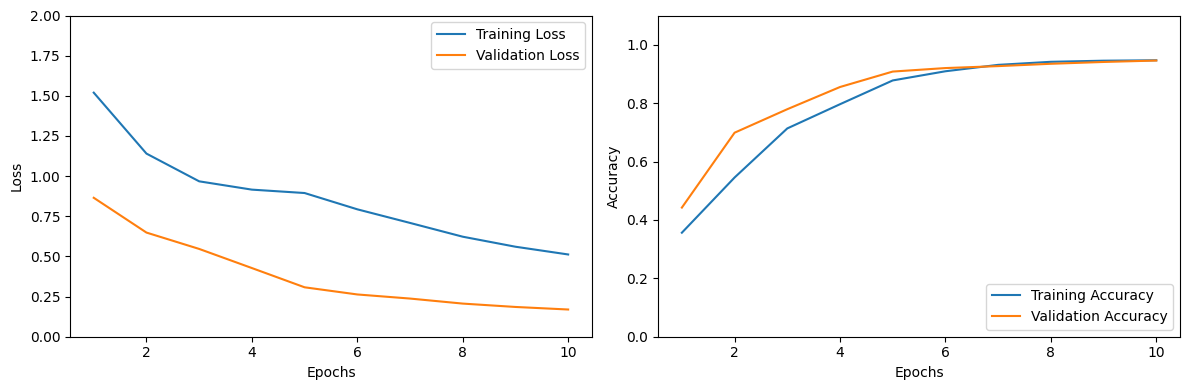

In [20]:
epochs = range(1, len(losses) + 1)
plt.figure(figsize=(12, 4))

# ---- Loss Plot ----
plt.subplot(1, 2, 1)
plt.plot(epochs, losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.ylim(0, 2)

# ---- Accuracy Plot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Load Model

In [21]:
best_checkpoint_path = checkpoints_path
checkpoint = torch.load(best_checkpoint_path)
best_epoch = checkpoint["epoch"]
model.load_state_dict(checkpoint["model_weight"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

best_val_accuracy, best_val_loss = validate(model, dataloader_valid_dataset, device)
print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")

Best model (from epoch 10) - Validation Loss: 0.169, Validation Accuracy: 0.946


# Evaluation

In [22]:
start_time = time.time()

test_acc, test_loss = validate(model, dataloader_test_dataset, device)
print(f"Test Accuracy: {test_acc:.3f}")

end_time = time.time()
test_time = end_time - start_time
print(f"Test Time: {test_time:.2f} seconds ---> {test_time/60:.2f} minutes")

Test Accuracy: 0.953
Test Time: 11.68 seconds ---> 0.19 minutes


In [23]:
def get_predictions_labels(model, dataloader, device):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x, y = x.to(device), y.to(device)

            logits = model(x)
            predictions = torch.argmax(logits, dim=1).cpu().numpy()

            all_predictions.extend(predictions)
            all_labels.extend(y.cpu().numpy())

    return all_predictions, all_labels

test_predictions, test_labels = get_predictions_labels(model, dataloader_test_dataset, device)

class_names = [str(i) for i in range(total_class)]
val_classification_report = classification_report(test_labels, test_predictions, target_names=class_names)

print("Classification Report:")
print(val_classification_report)

def class_accuracy(predictions, labels, num_classes):
    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    for pred, label in zip(predictions, labels):
        class_correct[label] += (pred == label)
        class_total[label] += 1

    class_acc = [class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(num_classes)]
    return class_acc

class_acc = class_accuracy(test_predictions, test_labels, total_class)

for i, acc in enumerate(class_acc):
    print(f"Class {i}: Accuracy = {acc:.3f}")

print()
print("brain_glioma: 0, brain_menin: 1, brain_tumor: 2")

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       750
           1       0.95      0.93      0.94       750
           2       0.97      0.96      0.96       750

    accuracy                           0.95      2250
   macro avg       0.95      0.95      0.95      2250
weighted avg       0.95      0.95      0.95      2250

Class 0: Accuracy = 0.976
Class 1: Accuracy = 0.927
Class 2: Accuracy = 0.957

brain_glioma: 0, brain_menin: 1, brain_tumor: 2
